# Superdoves and S2 chl-a 

using best atmospheric correction procedures for each wavelength

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import scipy as sp
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.dates as mdates

from sklearn.metrics import f1_score
from pylr2 import regress2

In [2]:
def p_sig(p_val):
    if p_val >= 0.05:
        return '(ns)'
    elif p_val >= 0.01:
        return '*'
    elif p_val >= 0.001:
        return '**'
    else:
        return '***'

In [3]:
def MAE(true, pred):
    return np.sum(np.abs(true - pred))/len(pred)
def MAPE(true, pred):
    return 100 * np.sum(np.abs((true - pred)/true))/len(pred)
def RMSE(true, pred):
    return np.sqrt(np.sum((true - pred)**2)/len(pred))

def RMSD(y_true, y_est):
    '''
    logspace RMSE
    '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**(np.sqrt(np.mean((y_true - y_est)**2)))-1

def MAD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the mean absolute difference (MAD) '''
    y_true = np.log10(y_true)
    y_est = np.log10(y_est)
    return 10**np.mean(np.abs(y_true - y_est))-1

def MAvD(y_true, y_est):
    '''mean average differnce - bias'''
    return np.sum((y_est - y_true)/len(y_est))

def MAPD(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median absolute percentage difference (MAPD) '''
    return np.nanmedian(np.abs((y_true - y_est) / y_true)) * 100


def MDSA(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the median symmetric accuracy (MdSA) '''
    return (np.exp(np.nanmedian(np.abs(np.log(y_est / y_true)))) - 1) * 100


def SSPB(y_true: np.ndarray, y_est: np.ndarray) -> float:
    ''' Return the symmetric signed percentage bias (SSPB) '''
    med = np.nanmedian( np.log(y_est / y_true) )
    return np.sign(med) * (np.exp(np.abs(med)) - 1) * 100

def MRD(true, pred):
    '''mean relative difference'''
    return np.sum(((pred - true)/true)) / len(pred)

In [4]:
SD_med = pd.read_csv('Superdoves_best_atmos_corr_med_56.147005__3.923311_24_jun.csv')

In [5]:
SD_med.date = pd.to_datetime(SD_med.date)

In [6]:
S2_med = pd.read_csv('Sentinel_2_best_atmos_corr_med_56.147005__3.923311.csv')

In [7]:
S2_med.date = pd.to_datetime(S2_med.date)

In [8]:
def chla_NIR_rat(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    just use NIR ratio 708/666 with no coefficients
    '''
    ratio = df[Rrs_708] / df[Rrs_666]
    return ratio

def chla_NIR_rat_org(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666',
                     a=61.324, b=-37.94):
    return a * chla_NIR_rat(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666) + b

def chla_NDCI(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    use NCDI NIR ratio (708-666)/(708+666)
    '''
    ratio = (df[Rrs_708] - df[Rrs_666]) / (df[Rrs_708] + df[Rrs_666])
    return ratio

def chla_NDCI_org(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666',
                  a=42.197, b=236.5, c=314.97):
    ratio = chla_NDCI(df, Rrs_708=Rrs_708, Rrs_666=Rrs_666)
    return a + (b*ratio) + (c*ratio**2)


def chla_OC4(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444], df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))

def chla_OC4_mod(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.3255, b=-2.7677,
             c=2.4409, d=-1.1288, e=-0.4990, returnX=False):
    '''4 band NASA alg (model L in claire neil paper)
    with Rrs_444 removed as we cant trust this one... '''
    X = np.log10(np.array(np.max([df[Rrs_492], df[Rrs_533]], axis=0)/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_OC3(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2424, b=-2.2146,
             c=1.5193, d=-0.7702,
             e=-0.4291, returnX=False):
    '''3 band NASA alg (model M in claire neil paper)'''
    X = np.log10(np.array(np.max([df[Rrs_444],
                                  df[Rrs_492]],
                                 axis=0)/(df[Rrs_566]), dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
                
def chla_OC2(df, Rrs_444='Rrs_444', Rrs_492='Rrs_492',
             Rrs_533='Rrs_533', Rrs_566='Rrs_566',
             a=0.2389, b=-1.9369,
             c=1.7627, d=-3.0777,
             e=-0.1054, returnX=False):
    '''2 band NASA alg (model N in claire neil paper)'''
    X = np.log10(np.array(df[Rrs_492]/df[Rrs_566], dtype=float))
    if returnX:
        return X
    else:
        return 10**(a + b*X + c*(X**2) + d*(X**3) + e*(X**4))
    
def chla_RBD(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666'):
    '''
    NIR/red band difference
    '''
    return df[Rrs_708] - df[Rrs_666]

def chla_RBR3(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666', Rrs_866='Rrs_866'):
    return (df[Rrs_666]**-1 - df[Rrs_708]**-1) * df[Rrs_866]

def chla_RBR3_org(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666', Rrs_866='Rrs_866',
                  a=-0.0620/0.016, b=0.1166/0.016
                 ):
    '''
    coefficients from quintin's paper 
    '''
    RBR3 = (df[Rrs_666]**-1 - df[Rrs_708]**-1) * df[Rrs_866]
    return a + RBR3*b

def chla_RBD_org(df, Rrs_708='Rrs_707', Rrs_666='Rrs_666',
                 #a=-0.0134/0.016, b=0.0258/0.016
                a=1.8, b=27580):
    '''
    NIR/red band difference with coeffs from 
    https://www.sciencedirect.com/science/article/pii/S0034425719302470?via%3Dihub
    
    '''
    rbd = df[Rrs_708] - df[Rrs_666]
    return a + b*rbd


In [9]:
S2_med[S2_med.Wavelength==443]

,Unnamed: 0,date,Wavelength,Rrs_S2_c2rcc,original_date,date_flag,Rrs_S2_acolite,Rrs_S2_polymer,Rrs_S2_c2rcX,Rrs_S2_c2rcc_CX,best_alg,Rrs_best
0,0,2022-03-01,443.0,0.000225,NaN,0,0.001242,0.003150,0.001200,0.000483,Rrs_S2_c2rcc,0.000225
8,8,2022-03-06,443.0,0.000333,NaN,0,0.000480,0.001679,0.000088,0.000232,Rrs_S2_c2rcc,0.000333
16,16,2022-03-08,443.0,0.000229,NaN,0,0.002573,0.004421,0.000096,0.000463,Rrs_S2_c2rcc,0.000229
24,24,2022-03-21,443.0,0.000165,NaN,0,0.000196,0.003593,0.000205,0.001334,Rrs_S2_c2rcc,0.000165
32,32,2022-03-23,443.0,0.000537,NaN,0,0.000049,0.011998,0.000247,0.002205,Rrs_S2_c2rcc,0.000537
40,40,2022-03-26,443.0,0.002897,NaN,0,0.001646,0.033592,0.000187,0.001215,Rrs_S2_c2rcc,0.002897
48,48,2022-03-28,443.0,0.000315,NaN,0,0.000694,0.007151,0.000173,0.000846,Rrs_S2_c2rcc,0.000315
56,56,2022-04-20,443.0,0.000225,NaN,0,0.000321,0.005303,0.003801,0.001654,Rrs_S2_c2rcc,0.000225
64,64,2022-04-22,443.0,0.000263,NaN,0,0.001975,0.004632,0.001509,0.000532,Rrs_S2_c2rcc,0.000263
72,72,2022-06-04,443.0,0.001192,NaN,0,0.002031,0.003927,0.001238,0.002384,Rrs_S2_c2rcc,0.001192


In [10]:
s2_dict = {'date':S2_med[S2_med.Wavelength==443.0].reset_index().date}
sd_dict = {'date':SD_med[SD_med.Wavelength==444.0].reset_index().date}

for wavelength in S2_med.Wavelength.unique():
    s2_dict['Rrs_'+str(int(wavelength))] = S2_med[S2_med.Wavelength==wavelength].reset_index().Rrs_S2_c2rcc_CX

for wavelength in SD_med.Wavelength.unique():
    sd_dict['Rrs_'+str(int(wavelength))] = SD_med[SD_med.Wavelength==wavelength].reset_index().Acolite

    
s2_chla = pd.DataFrame(data=s2_dict)
sd_chla = pd.DataFrame(data=sd_dict)

In [11]:
sd_chla = sd_chla.groupby('date').median().reset_index()
# take median of Rrs for days where we have multiple overpasses

In [12]:
s2_chla

,date,Rrs_443,Rrs_492,Rrs_560,Rrs_665,Rrs_704,Rrs_740,Rrs_783,Rrs_865
0,2022-03-01,0.000483,0.000653,0.001372,0.000389,0.001157,0.000259,0.000255,0.000095
1,2022-03-06,0.000232,0.000274,0.000459,0.000241,0.000700,0.000184,0.000190,0.000077
2,2022-03-08,0.000463,0.000560,0.000847,0.000329,0.000696,0.000175,0.000175,0.000069
3,2022-03-21,0.001334,0.001896,0.001975,0.000205,0.000185,0.000056,0.000055,0.000020
4,2022-03-23,0.002205,0.002462,0.001377,0.000153,0.000115,0.000052,0.000048,0.000018
5,2022-03-26,0.001215,0.001455,0.001154,0.000146,0.000120,0.000079,0.000074,0.000026
6,2022-03-28,0.000846,0.001052,0.001062,0.000214,0.000217,0.000057,0.000051,0.000020
7,2022-04-20,0.001654,0.002240,0.004269,0.000784,0.001308,0.000227,0.000231,0.000082
8,2022-04-22,0.000532,0.000633,0.001144,0.000421,0.001382,0.000282,0.000263,0.000100
9,2022-06-04,0.002384,0.003169,0.003083,0.000457,0.000403,0.000110,0.000095,0.000035


In [13]:
# sentinel 2

s2_chla['NIR'] = chla_NIR_rat(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['NDCI'] = chla_NDCI(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['RBD'] = chla_RBD(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['RBR3'] = chla_RBR3(s2_chla, Rrs_708='Rrs_704',
                            Rrs_666='Rrs_665', Rrs_866='Rrs_865')

s2_chla['NIR_org'] = chla_NIR_rat_org(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['NDCI_org'] = chla_NDCI_org(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['RBD_org'] = chla_RBD_org(s2_chla, Rrs_708='Rrs_704', Rrs_666='Rrs_665')
s2_chla['RBR3_org'] = chla_RBR3_org(s2_chla, Rrs_708='Rrs_704',
                            Rrs_666='Rrs_665', Rrs_866='Rrs_865')


s2_chla['OC3_X'] = chla_OC3(s2_chla, returnX=True,
                            Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                            Rrs_566='Rrs_560',)
s2_chla['OC2_X'] = chla_OC2(s2_chla, returnX=True,
                            Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                            Rrs_566='Rrs_560',)


s2_chla['OC3'] = chla_OC3(s2_chla,
                          Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                          Rrs_566='Rrs_560',)
s2_chla['OC2'] = chla_OC2(s2_chla,
                          Rrs_444='Rrs_443', Rrs_492='Rrs_492',
                          Rrs_566='Rrs_560',)

In [14]:
# SD
sd_chla['NIR'] = chla_NIR_rat(sd_chla)
sd_chla['NDCI'] = chla_NDCI(sd_chla)
sd_chla['RBD'] = chla_RBD(sd_chla)
sd_chla['RBR3'] = chla_RBR3(sd_chla)

sd_chla['NIR_org'] = chla_NIR_rat_org(sd_chla)
sd_chla['NDCI_org'] = chla_NDCI_org(sd_chla)
sd_chla['RBD_org'] = chla_RBD_org(sd_chla)
sd_chla['RBR3_org'] = chla_RBR3_org(sd_chla)

sd_chla['OC4_X'] = chla_OC4(sd_chla, returnX=True)
sd_chla['OC4_mod_X'] = chla_OC4_mod(sd_chla, returnX=True)

sd_chla['OC3_X'] = chla_OC3(sd_chla, returnX=True)
sd_chla['OC2_X'] = chla_OC2(sd_chla, returnX=True)

sd_chla['OC4'] = chla_OC4(sd_chla)
sd_chla['OC3'] = chla_OC3(sd_chla)
sd_chla['OC2'] = chla_OC2(sd_chla)


In [15]:
insitu_chl = pd.read_csv('data/chl-a/airthrey_chl.csv')
insitu_chl.Date = pd.to_datetime(insitu_chl.Date, dayfirst=True)

In [16]:
# not my finest work, but does the job
# by the way, the job being that we are finding the closest in-situ measurements to the S2 data! 

# START WITH SENTINEL 2


for alg in ['OC3_X', 'OC2_X',
            'OC3', 'OC2', 'NIR', 'NDCI', 'RBD', 'RBR3',
            'NIR_org', 'NDCI_org', 'RBD_org', 'RBR3_org']:
    selected_dates = []
    date_diffs = []
    selected_chl = []
    for s2_date in insitu_chl.Date:
        date_deltas = []
        for ins_date in s2_chla.date:
            #print(ins_date)
            date_deltas.append(s2_date - ins_date)
        date_deltas = np.array(np.abs(date_deltas))
        min_ind = np.where(date_deltas==date_deltas.min())
        #print(min_ind)
        selected_dates.append(s2_chla.date[min_ind[0][0]])
        date_diffs.append(date_deltas[min_ind[0][0]])
        selected_chl.append(s2_chla[alg][min_ind[0][0]])
    

    insitu_chl[alg] =  selected_chl
    insitu_chl['sat_date'] = selected_dates
    insitu_chl['date_diff'] = date_diffs

In [17]:
insit_reduced_S2 = insitu_chl.loc[insitu_chl.groupby('sat_date').date_diff.idxmin()]
insit_reduced_S2 = insit_reduced_S2[insit_reduced_S2.date_diff<'5d']
insit_reduced_S2 #= sd_reduced[sd_reduced.date.dt.year==2023]
insit_reduced_S2['year'] = insit_reduced_S2.Date.dt.year

In [18]:
# not my finest work, but does the job
# by the way, the job being that we are finding the closest in-situ measurements to the superdoves data! 


# NOW SUPERDOVES

for alg in ['OC4_X', 'OC4_mod_X', 'OC3_X', 'OC2_X', 'OC4',
            'OC3', 'OC2', 'NIR', 'NDCI', 'RBD', 'RBR3',
            'NIR_org', 'NDCI_org', 'RBD_org', 'RBR3_org']:
    selected_dates = []
    date_diffs = []
    selected_chl = []
    for sd_date in insitu_chl.Date:
        date_deltas = []
        for ins_date in sd_chla.date:
            #print(ins_date)
            date_deltas.append(sd_date - ins_date)
        date_deltas = np.array(np.abs(date_deltas))
        min_ind = np.where(date_deltas==date_deltas.min())
        #print(min_ind)
        selected_dates.append(sd_chla.date[min_ind[0][0]])
        date_diffs.append(date_deltas[min_ind[0][0]])
        selected_chl.append(sd_chla[alg][min_ind[0][0]])
    

    insitu_chl[alg] =  selected_chl
    insitu_chl['sat_date'] = selected_dates
    insitu_chl['date_diff'] = date_diffs

In [19]:
insit_reduced_SD = insitu_chl.loc[insitu_chl.groupby('sat_date').date_diff.idxmin()]
insit_reduced_SD = insit_reduced_SD[insit_reduced_SD.date_diff<'100d']
insit_reduced_SD #= sd_reduced[sd_reduced.date.dt.year==2023]
insit_reduced_SD['year'] = insit_reduced_SD.Date.dt.year

In [20]:
def RBI_polyfit(df, alg, chla_name='Chl-a', debug=False, returnCoeff=False, log=False):
    '''
    fits a linear model to the data in df[alg] against df[chla_name] 
    '''
    if debug:
        print(df[alg])
        print(df[chla_name])
    if not log:
        coeff = np.polyfit(df[alg],
                           df[chla_name], deg=1)
    elif log:
        coeff = np.polyfit(df[alg],
                           np.log10(df[chla_name]), deg=1)
    if debug:
        print(coeff)
        
    if returnCoeff:
        return coeff
    else:
        if not log:
            return np.polyval(coeff, df[alg])
        elif log:
            return 10**np.polyval(coeff, log10(df[alg]))
        
def RBI_RMA(df, alg, chla_name='Chl-a', debug=False, returnCoeff=False, log=False):
    '''
    fits a linear model to the data in df[alg] against df[chla_name] 
    '''
    if debug:
        print(df[alg])
        print(df[chla_name])
    if not log:
        res = regress2(df[alg], df[chla_name],
                         _method_type_2="reduced major axis")

    elif log:
        res = regress2(df[alg], np.log10(df[chla_name]),
                         _method_type_2="reduced major axis")
    
    coeff = np.array([res['slope'], res['intercept']])
    
    if debug:
        print(res)
        
    if returnCoeff:
        return coeff
    else:
        if not log:
            return np.polyval(coeff, df[alg])
        elif log:
            return 10**np.polyval(coeff, log10(df[alg]))
    
def OC_polyfit(df, alg, chla_name='Chl-a', debug=False, returnCoeff=False, deg=4):
    '''
    fits a 4th order polynomial to the data in df[alg] against df[chla_name]\
    alg should be the X output from one of the OC algorithms
    uses log10 of chl-a to match 
    '''
    coeff = np.polyfit(df[alg],
                       np.log10(df[chla_name]), deg=deg)
    if debug:
        print(coeff)
        print(df[alg])
        print(df[chla_name])
    if returnCoeff:
        return coeff
    else:
        return 10**(np.polyval(coeff, df[alg]))

In [21]:
regress2(np.array([1, 2, 3]), np.array([1, 2, 3]), _method_type_2="reduced major axis")

{'slope': 1.0,
 'intercept': 0.0,
 'r': 1.0000000000000004,
 'std_slope': 0.0,
 'std_intercept': 0.0,
 'predict': array([1., 2., 3.])}

In [22]:


for OC in ['OC2_X', 'OC3_X']:
    print(OC)


    # get coefficients
    OC_coeff_S2 = OC_polyfit(insit_reduced_S2[insit_reduced_S2.date_diff<='1 days'], OC, returnCoeff=True)
    s2_chla[OC[:-2] + '_tuned'] = 10**(np.polyval(OC_coeff_S2, s2_chla[OC]))
    insit_reduced_S2[OC[:-2] + '_tuned'] = 10**(np.polyval(OC_coeff_S2, insit_reduced_S2[OC]))
    
    print('S2_coeff:')
    print(OC_coeff_S2)
    
    # get coefficients
    OC_coeff_SD = OC_polyfit(insit_reduced_SD[insit_reduced_SD.date_diff<='1 days'], OC, returnCoeff=True)
    # populate dfs
    sd_chla[OC[:-2] + '_tuned'] = 10**(np.polyval(OC_coeff_SD, sd_chla[OC]))    
    insit_reduced_SD[OC[:-2] + '_tuned'] = 10**(np.polyval(OC_coeff_SD, insit_reduced_SD[OC]))   
    
    print('SD_coeff: ')
    print(OC_coeff_SD)

    
print('OC4_X')
print('SD_coeff:')
OC_coeff_SD = OC_polyfit(insit_reduced_SD, 'OC4_X', returnCoeff=True)
print(OC_coeff_SD)
sd_chla['OC4_tuned'] = 10**(np.polyval(OC_coeff_SD, sd_chla['OC4_X']))
insit_reduced_SD['OC4_tuned'] = 10**(np.polyval(OC_coeff_SD, insit_reduced_SD['OC4_X']))

OC2_X
S2_coeff:
[ 52.75531716  -8.57170808 -13.63488302  -2.19803206   1.23223006]
SD_coeff: 
[-1.01227854e+03 -6.18968883e+02 -1.07200947e+02 -5.98662394e+00
  7.00895076e-01]
OC3_X
S2_coeff:
[ 52.21170505 -11.29312089 -14.27693158  -1.9865777    1.27518218]
SD_coeff: 
[-446.86151603 -201.59773025   -4.79645411    1.20820977    0.71501882]
OC4_X
SD_coeff:
[-1.81471459e+03  2.37511164e+02  6.79003127e+01 -5.19819726e+00
  5.88600577e-01]


In [23]:
insit_reduced_SD

,Date,Chl-a,OC3_X,sat_date,date_diff,OC2_X,OC3,OC2,NIR,NDCI,...,NDCI_org,RBD_org,RBR3_org,OC4_X,OC4_mod_X,OC4,year,OC2_tuned,OC3_tuned,OC4_tuned
0,2022-07-05,2.663,-0.158048,2022-07-04,1 days,-0.323260,4.296707,14.191643,2.043316,0.342822,...,160.291948,159.132576,12.001248,-0.158048,-0.181068,6.730458,2022,19.446117,8.342880,10.871453
1,2022-07-07,2.592,-0.069458,2022-07-07,0 days,-0.248330,2.533953,7.504535,2.391488,0.410288,...,192.251109,130.261076,19.445751,-0.064546,-0.064546,3.270449,2022,16.068102,4.625006,12.931212
2,2022-07-20,6.163,-0.215524,2022-07-10,10 days,-0.215524,6.266944,5.872326,2.002922,0.333982,...,156.316747,126.257062,12.940572,-0.072081,-0.072081,3.452151,2022,10.570336,19.314577,15.070947
4,2022-08-04,8.361,-0.273982,2022-08-10,6 days,-0.292907,9.476118,10.815028,1.926368,0.316559,...,148.626165,147.133644,5.917124,-0.090404,-0.090404,3.948760,2022,22.943611,44.887146,20.738415
5,2022-08-19,37.789,-0.327097,2022-08-20,1 days,-0.327097,14.170480,14.707961,2.311943,0.396125,...,185.304040,294.997809,7.470208,-0.100764,-0.100764,4.268469,2022,18.342895,55.787271,23.536019
6,2022-08-25,89.650,-0.294393,2022-08-27,2 days,-0.422817,11.027165,40.017341,2.043362,0.342832,...,160.296391,430.506605,7.549986,-0.107714,-0.107714,4.500733,2022,0.031758,53.799012,24.843283
8,2022-09-09,16.429,-0.109405,2022-09-10,1 days,-0.249181,3.190226,7.554362,1.508576,0.202735,...,103.089514,109.344877,1.423687,-0.088629,-0.088629,3.896978,2022,16.233534,5.313731,20.200022
9,2022-09-12,21.707,-0.228170,2022-09-12,0 days,-0.319421,6.835767,13.697462,1.726753,0.266527,...,127.605034,123.471069,2.190497,-0.111117,-0.111117,4.620084,2022,20.419331,23.616105,25.238746
10,2023-04-03,8.825,-0.054608,2023-04-03,0 days,-0.054608,2.333387,2.240922,1.720210,0.264763,...,126.892482,81.059462,5.117089,-0.036104,-0.036104,2.683231,2023,6.308540,4.608852,7.087945
12,2023-04-14,5.158,0.067260,2023-04-14,0 days,-0.017717,1.259146,1.878390,1.389904,0.163146,...,89.164520,61.794303,0.802848,0.067260,-0.017717,1.412645,2023,5.979325,5.059377,3.813070


In [24]:
for alg in ['NIR', 'NDCI', 'RBD', 'RBR3',
            'OC2_X', 'OC3_X'
           ]:
    print(alg)    
    
    print('SD_coeff:')
    coeff_SD = RBI_polyfit(insit_reduced_SD[insit_reduced_SD.date_diff<='1 days'],
                           alg, returnCoeff=True, log=True)
    print(coeff_SD)
    sd_chla[alg + '_tuned'] = 10**np.polyval(coeff_SD, sd_chla[alg])
    insit_reduced_SD[alg + '_tuned'] = 10**np.polyval(coeff_SD, insit_reduced_SD[alg])

    
    print('S2_coeff:')
    coeff_S2 = RBI_polyfit(insit_reduced_S2[insit_reduced_S2.date_diff<='1 days'],
                           alg, returnCoeff=True, log=True, debug=False)
    print(coeff_S2)
    s2_chla[alg + '_tuned'] = 10**np.polyval(coeff_S2, s2_chla[alg])
    insit_reduced_S2[alg + '_tuned'] = 10**np.polyval(coeff_S2, insit_reduced_S2[alg])


NIR
SD_coeff:
[-0.46770934  1.87657545]
S2_coeff:
[0.55386291 0.38444413]
NDCI
SD_coeff:
[-1.87558786  1.55127892]
S2_coeff:
[1.67431552 0.98119468]
RBD
SD_coeff:
[105.33996671   0.54325279]
S2_coeff:
[256.45606953   0.91358273]
RBR3
SD_coeff:
[-0.32484211  1.50231199]
S2_coeff:
[5.61813791 0.99459553]
OC2_X
SD_coeff:
[-1.31846999  0.75018395]
S2_coeff:
[-1.28859524  1.03740094]
OC3_X
SD_coeff:
[-2.91864966  0.65474659]
S2_coeff:
[-1.24879141  1.04810289]


In [25]:
# NIR
# SD_coeff:
# [-0.22961291  1.4588519 ]
# S2_coeff:
# [0.53913224 0.36363481]
# NDCI
# SD_coeff:
# [-0.50239614  1.18892694]
# S2_coeff:
# [1.55708019 0.95527947]
# RBD
# SD_coeff:
# [76.83399319  0.67388964]
# S2_coeff:
# [291.58490955   0.84355776]
# RBR3
# SD_coeff:
# [-0.2467998   1.38701688]
# S2_coeff:
# [5.59987381 0.9646241 ]
# OC2_X
# SD_coeff:
# [-1.95136073  0.62528131]
# S2_coeff:
# [-1.32213973  1.0059512 ]
# OC3_X
# SD_coeff:
# [-2.39199957  0.75019979]
# S2_coeff:
# [-1.29289795  1.01289393]

In [26]:
insit_reduced_S2.columns

Index(['Date', 'Chl-a', 'OC3_X', 'sat_date', 'date_diff', 'OC2_X', 'OC3',
       'OC2', 'NIR', 'NDCI', 'RBD', 'RBR3', 'NIR_org', 'NDCI_org', 'RBD_org',
       'RBR3_org', 'year', 'OC2_tuned', 'OC3_tuned', 'NIR_tuned', 'NDCI_tuned',
       'RBD_tuned', 'RBR3_tuned', 'OC2_X_tuned', 'OC3_X_tuned'],
      dtype='object')

In [27]:
insit_melt_S2 = insit_reduced_S2.melt(value_vars=['OC3', 'OC3_tuned', 
                                                  'OC2', 'OC2_tuned',
                                                  'OC3_X_tuned', 'OC2_X_tuned',
                                                    'NIR', 'NDCI', 'RBD', 'RBR3',
                                                    'NIR_tuned', 'NDCI_tuned',
                                                    'RBD_tuned', 'RBR3_tuned',
                                                  'NIR_org', 'NDCI_org', 'RBD_org', 'RBR3_org'],
                                id_vars=['Date',
                                          'Chl-a',
                                          'sat_date',
                                          'date_diff'],
                                value_name='Satellite_chla',
                                var_name='Algorithm')
insit_melt_S2['Sensor'] = 'S2'

In [28]:
insit_melt_SD = insit_reduced_SD.melt(value_vars=['OC4', 'OC4_tuned',
                                                  'OC3', 'OC3_tuned',
                                                  'OC2', 'OC2_tuned',
                                                  'OC3_X_tuned', 'OC2_X_tuned',
                                                    'NIR', 'NDCI', 'RBD', 'RBR3',
                                                    'NIR_tuned', 'NDCI_tuned',
                                                    'RBD_tuned', 'RBR3_tuned',
                                                  'NIR_org', 'NDCI_org', 'RBD_org', 'RBR3_org'],
                                id_vars=['Date',
                                          'Chl-a',
                                          'sat_date',
                                          'date_diff'],
                                value_name='Satellite_chla',
                                var_name='Algorithm')
insit_melt_SD['Sensor'] = 'SD'

In [29]:
insit_melt = pd.concat([insit_melt_SD, insit_melt_S2])

In [30]:
insit_melt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 323
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype          
---  ------          --------------  -----          
 0   Date            784 non-null    datetime64[ns] 
 1   Chl-a           784 non-null    float64        
 2   sat_date        784 non-null    datetime64[ns] 
 3   date_diff       784 non-null    timedelta64[ns]
 4   Algorithm       784 non-null    object         
 5   Satellite_chla  784 non-null    float64        
 6   Sensor          784 non-null    object         
dtypes: datetime64[ns](2), float64(2), object(2), timedelta64[ns](1)
memory usage: 49.0+ KB


In [31]:
insit_melt.Algorithm = insit_melt.Algorithm.replace({'OC3':'OC3_orig',
                              'OC2':'OC2_orig',
                              'NIR_org':'NIR_orig',
                              'NDCI_org':'NDCI_orig',
                              'RBD_org':'RBD_orig',
                              'RBR3_org':'RBR3_orig+5'})

In [32]:
insit_melt.Algorithm = insit_melt.Algorithm.replace({'RBR3_orig_5':'RBR3_orig+5'})

In [33]:
# add 5 to satellite chla of RBR3 alg to make logs work
insit_melt.loc[(insit_melt.Algorithm=='RBR3_orig+5'), 'Satellite_chla']+=5

In [34]:
not_tuned = insit_melt.Algorithm.isin(['OC3_orig', 'OC2_orig', 'NIR_orig',
                                       'NDCI_orig', 'RBD_orig', 'RBR3_orig+5'])

In [35]:
# check min value we're interested in is +ve
insit_melt.loc[(insit_melt.Algorithm=='RBR3_orig+5') & (insit_melt.date_diff <= '1 days'),
               'Satellite_chla'].min()

0.8759286176089809

In [36]:
insit_melt

,Date,Chl-a,sat_date,date_diff,Algorithm,Satellite_chla,Sensor
0,2022-07-05,2.663,2022-07-04,1 days,OC4,6.730458,SD
1,2022-07-07,2.592,2022-07-07,0 days,OC4,3.270449,SD
2,2022-07-20,6.163,2022-07-10,10 days,OC4,3.452151,SD
3,2022-08-04,8.361,2022-08-10,6 days,OC4,3.948760,SD
4,2022-08-19,37.789,2022-08-20,1 days,OC4,4.268469,SD
...,...,...,...,...,...,...,...
319,2023-07-20,68.487,2023-07-19,1 days,RBR3_orig+5,1.300693,S2
320,2023-08-08,71.458,2023-08-08,0 days,RBR3_orig+5,1.693837,S2
321,2023-09-05,28.054,2023-09-04,1 days,RBR3_orig+5,1.498924,S2
322,2023-09-12,18.055,2023-09-12,0 days,RBR3_orig+5,0.875929,S2


21.827532801372648
22.22144312587738
35.56924088309962
0.3287487501235051 -0.2843542737427515


NameError: name 'pfit' is not defined

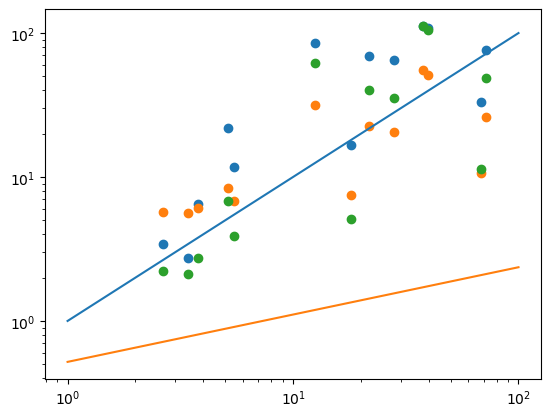

In [37]:
fig, ax = plt.subplots()

ax = plt.gca()


NIR_O = insit_melt[(insit_melt.date_diff <= '1 days') &\
                      (insit_melt.Algorithm == 'NIR_orig')&\
                      (insit_melt.Sensor=='S2')]

NIR_T = insit_melt[(insit_melt.date_diff <= '1 days') &\
                      (insit_melt.Algorithm == 'NIR_tuned')&\
                      (insit_melt.Sensor=='S2')]


plt.plot([1, 10, 100], [1, 10, 100])


ax.scatter(NIR_O['Chl-a'].values, 10**(np.log10(NIR_O['Satellite_chla'])-0.))
ax.scatter(NIR_T['Chl-a'].values, NIR_T['Satellite_chla'].values)

res = sp.stats.linregress(np.log10(NIR_O['Satellite_chla']),
                              np.log10(NIR_O['Chl-a']))

m, c =  np.polyfit(insit_reduced_S2[insit_reduced_S2.date_diff <='1 day']['NIR'],
                              np.log10(insit_reduced_S2[insit_reduced_S2.date_diff <='1 day']['Chl-a']), 1)

m, c =  np.polyfit(np.log10(insit_reduced_S2[insit_reduced_S2.date_diff <='1 day']['Chl-a']),
                               np.log10(insit_reduced_S2[insit_reduced_S2.date_diff <='1 day']['NIR']),1)

x = insit_reduced_S2[insit_reduced_S2.date_diff <='1 day']['NIR']
y = 10**((np.log10(x)- c)/m)

# ax.scatter(insit_reduced_S2['Chl-a'], insit_reduced_S2['NIR_org'])
ax.scatter(insit_reduced_S2[insit_reduced_S2.date_diff <='1 day']['Chl-a'], y)

ax.plot([1, 10, 100], 10**((m*np.log10([1, 10, 100]))+ c)
)

ax.set_yscale('log')
ax.set_xscale('log')

print(RMSE(NIR_O['Chl-a'], 10**(np.log10(NIR_O['Satellite_chla'])-0.25)))
print(RMSE(NIR_T['Chl-a'], NIR_T['Satellite_chla']))
print(RMSE(insit_reduced_S2[insit_reduced_S2.date_diff <='1 day']['Chl-a'], y))



print(m, c)
print(pfit)

# x = np.array([1, 10, 100]) # 1.84483897 0.97841096 0.55386291 0.38444413
# y = 10**((np.log10(x) * 0.55386291) + 0.38444413)



plt.plot()

In [38]:
insit_reduced_S2

,Date,Chl-a,OC3_X,sat_date,date_diff,OC2_X,OC3,OC2,NIR,NDCI,...,RBR3_org,year,OC2_tuned,OC3_tuned,NIR_tuned,NDCI_tuned,RBD_tuned,RBR3_tuned,OC2_X_tuned,OC3_X_tuned
0,2022-07-05,2.663,0.660774,2022-07-04,1 days,0.622045,0.137530,0.091108,0.674146,-0.194639,...,-4.116500,2022,2.658064,2.656465,5.725698,4.521759,7.980063,6.433045,1.721224,1.670836
2,2022-07-20,6.163,-0.126991,2022-07-16,4 days,-0.126991,3.544882,3.308045,1.971025,0.326832,...,-3.339030,2022,21.025627,21.573769,29.931045,33.760903,10.236654,25.573478,15.886973,16.094903
3,2022-07-27,5.465,0.155142,2022-07-28,1 days,0.155142,0.855589,0.931703,0.811570,-0.104015,...,-4.066981,2022,3.644149,4.087174,6.822485,6.412702,8.031689,7.024127,6.878364,7.150927
5,2022-08-19,37.789,-0.306842,2022-08-20,1 days,-0.306842,12.117813,12.222596,2.447873,0.419932,...,-2.572483,2022,21.787953,21.361781,54.983249,48.338575,57.804204,99.710844,27.089186,26.995068
9,2022-09-12,21.707,-0.359221,2022-09-12,0 days,-0.359221,18.303624,20.092822,1.749911,0.272704,...,-3.384931,2022,34.525516,34.624188,22.576419,27.402292,17.963321,23.572370,31.643991,31.383027
10,2023-04-03,8.825,-0.108878,2023-04-07,4 days,-0.108878,3.180290,2.982911,0.730631,-0.155648,...,-4.070137,2023,21.300540,22.087414,6.153378,5.255223,7.933928,6.984884,15.055710,15.278102
12,2023-04-14,5.158,-0.182296,2023-04-15,1 days,-0.182296,5.021042,4.667617,0.973801,-0.013274,...,-3.892988,2023,19.498384,19.451499,8.390662,9.098517,8.169453,9.565954,18.720036,18.869160
13,2023-04-25,3.189,0.387426,2023-04-22,3 days,0.387426,0.361406,0.373013,0.759957,-0.136392,...,-4.134296,2023,0.105723,0.076238,6.387869,5.660206,8.016136,6.233000,3.452752,3.666810
16,2023-05-17,3.483,0.339844,2023-05-15,2 days,0.339844,0.425889,0.459231,0.661071,-0.204042,...,-4.318426,2023,0.189561,0.160082,5.631017,4.360770,7.737338,4.495169,3.976299,4.204439
17,2023-05-24,3.776,0.124190,2023-05-25,1 days,0.104360,0.975493,1.128371,0.725261,-0.159245,...,-4.117188,2023,7.093501,6.295987,6.111382,5.182851,8.035137,6.425191,7.996926,7.816561


In [39]:
np.polyfit(np.log10(NIR_O['Satellite_chla']),
                              np.log10(NIR_O['Chl-a']), 1)

array([0.73735952, 0.10429115])

Text(0.5, 1.0, 'OC3_orig')
Text(0.5, 1.0, 'OC2_orig')
Text(0.5, 1.0, 'NIR_orig')
Text(0.5, 1.0, 'NDCI_orig')
Text(0.5, 1.0, 'RBD_orig')
Text(0.5, 1.0, 'RBR3_orig+5')


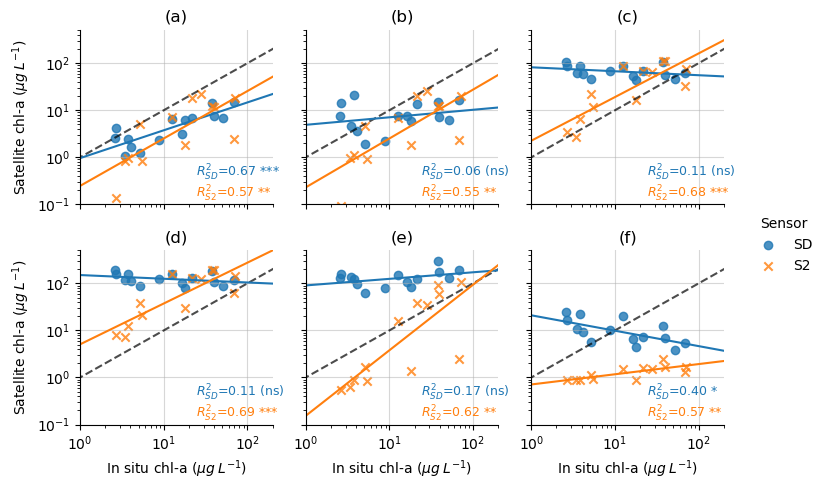

In [44]:
def annotate(data, x='Chl-a', y='sdfkjdf', order=1,
             plot=True, lims=None, text_size=9., **kws):
    
    ax = plt.gca()
    if data.Algorithm.values[0] == 'RBR3_orig_5':
        text_locs = ((0.6, 0.16), (0.6, 0.04))
    else:
        text_locs = ((0.6, 0.16), (0.6, 0.04))

    res = sp.stats.linregress(np.log10(data.dropna()[x]**order),
                              np.log10(data.dropna()[y]))
    if data.Sensor.values[0] == 'SD':
        textstr = '\n'.join((
#                              r'SuperDoves',
                             r'$R_{{SD}}^2$={:.2f} {}'.format(res.rvalue**2, p_sig(res.pvalue)),
#                              r'Slope = {:.2f}'.format(res.slope),
        ))
        ax.text(*text_locs[0], textstr, size=text_size,
            transform=ax.transAxes, bbox=None,
                color=sns.color_palette()[0],
               #fontweight='bold'
               )

        m = res.slope
        c = res.intercept

        if plot:
            ax.plot(np.logspace(-10, 4, num=1000),
                    10**((np.log10(np.logspace(-10, 4, num=1000)) * m) + c),
                    color=sns.color_palette()[0])

            
    if data.Sensor.values[0] == 'S2':
        textstr = '\n'.join((
#                              r'Sentinel-2',
                             r'$R_{{S2}}^2$={:.2f} {}'.format(res.rvalue**2, p_sig(res.pvalue)),
#                              r'Slope = {:.2f}'.format(res.slope),
                                ))
        ax.text(*text_locs[1], textstr, size=text_size,
            transform=ax.transAxes, bbox=None,
                color=sns.color_palette()[1],
               #fontweight='bold'
               )

        m = res.slope
 
        c = res.intercept

        if plot:
            ax.plot(np.logspace(-10, 4, num=1000),
                    10**((np.log10(np.logspace(-10, 4, num=1000)) * m) + c),
                    color=sns.color_palette()[1])


    

g = sns.lmplot(data=insit_melt[(insit_melt.date_diff <= '1 days')& not_tuned],
               x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
               ci=None, fit_reg=False,
               col_wrap=3, markers=['o', 'x'],
               col_order=['OC3_orig', 'OC2_orig', 'NIR_orig',
                           'NDCI_orig', 'RBD_orig', 'RBR3_orig+5',
                          ],
               facet_kws={'sharey':True, 'sharex':True}, height=2.5)

g.set_titles("{col_name}")


# ylims = np.array([[0.1,500], [0.08,500], [1,500], [5,500], [0.3,500], [0.1,500]])
titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for i, ax in enumerate(g.axes):
#     ax.set_xlim(0.1, 5e2)
#     ax.set_ylim(0.1, 5e2)
#     ax.plot([1e0, 100], [1e0, 100], 'k--', alpha=0.6)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.set_yscale('log')
    ax.set_xscale('log')


    lims = [np.min([xlim, ylim]), np.max([xlim, ylim])]
    ax.plot(np.logspace(-2, 3), np.logspace(-2, 3),
            'k--', alpha=0.7)
    
#     ax.set_ylim(ylims[i, 0], ylims[i, 1])
    ax.set_ylim(0.1, 500)
    ax.set_xlim(1, 200)
    ax.grid(alpha=0.5)
    if i in [3, 4, 5]:
        ax.set_xlabel('In situ chl-a ($\mu g \: L^{-1}$)')
    else:
        ax.set_xlabel('')
    if i in [0, 3]:
        ax.set_ylabel('Satellite chl-a ($\mu g \: L^{-1}$)')
    else:
        ax.set_ylabel('')
    print(ax.title)
    ax.set_title(titles[i])
    
# plt.savefig('figures_for_paper/alg_comparison_NOT.svg', dpi=300)

g.map_dataframe(annotate, y='Satellite_chla', plot=True, offset=10)# lims=[0.1, 100])
for i, ax in enumerate(g.axes):
    ax.set_ylabel('Satellite chl-a ($\mu g \: L^{-1}$)')

plt.savefig('figures_for_paper/SD_S2_chla_orig.svg', dpi=300)

    
plt.show()

first look at original algorithms to understand which are suitable for further tuning:

# for superdoves (acolite product):

- OC3, RBR3 all have significant fits with good R^2

# for S2 (C2RCC_Complex_X)

- All algorithms!

## now, should tabulate this finding with more metrics:

- I'm using logspace metrics
- for RBR3, I'm first adding 5 to the y_true and y_pred to deal with the -ve values 

In [46]:
def r2_rmse(g, logspace=True):
    # NOTE: slope is the logspace slope!
    try:
        if logspace:
            x = np.log10(g.dropna()['Chl-a'] )
            y = np.log10(g.dropna()['Satellite_chla'])
                
            r2 = sp.stats.pearsonr(x, y)[0]**2
            p_val = sp.stats.linregress(x, y).pvalue
            slope = sp.stats.linregress(x, y).slope
            rmse = 10**(np.sqrt(mean_squared_error(x, y))) - 1
            mapd = (MAPD(x, y)) # doesn't need to be backtransformed to linear space as it is a %
            mavd = 10**(MAvD(x, y)) - 1
#             mrd = (MRD(x, y)) # doesn't need to be backtransformed to linear space as it is a %
        else:
            x = g.dropna()['Chl-a']
            y = g.dropna()['Satellite_chla']
            r2 = sp.stats.pearsonr(x, y)[0]**2
            p_val = sp.stats.linregress(x, y).pvalue
            slope = sp.stats.linregress(x, y).slope
            rmse = np.sqrt(mean_squared_error(x, y))
            mapd = MAPD(x, y)
            mavd = MAvD(x, y)
#             mrd = MRD(x, y)
        
        return pd.Series(dict(r2 = r2,
                              p_val = p_val,
                              slope=slope,
                              rmse = rmse,
                              mapd=mapd,
                              mavd=mavd
                                        ))
    except ValueError:
        return pd.Series(dict(r2 = np.nan,
                              p_val = np.nan,
                              slope=np.nan, 
                              rmse = np.nan,
                              mapd=np.nan,
                              mavd=np.nan,
#                               mrd=np.nan
                                          ))

In [47]:
indi = (insit_melt.date_diff <= '1 days')& not_tuned

metrics = insit_melt[indi].groupby(['Algorithm',
                                    'Sensor']).apply(r2_rmse,
                                                      )
metrics = metrics.reset_index()
metrics[metrics.Sensor=='S2']

,Algorithm,Sensor,r2,p_val,slope,rmse,mapd,mavd
0,NDCI_orig,S2,0.686971,0.000462,0.867783,3.212775,58.187001,2.563780
2,NIR_orig,S2,0.684090,0.000486,0.927756,1.569680,27.388547,0.859274
4,OC2_orig,S2,0.546087,0.003903,1.039109,4.660654,32.365000,-0.745746
6,OC3_orig,S2,0.566037,0.003006,1.007840,4.457910,32.549314,-0.748137
8,RBD_orig,S2,0.616441,0.001474,1.392878,3.719587,69.455137,-0.566005
10,RBR3_orig+5,S2,0.573433,0.002721,0.216683,12.266313,93.779996,-0.911298


In [48]:
metrics[metrics.Sensor=='SD']

,Algorithm,Sensor,r2,p_val,slope,rmse,mapd,mavd
1,NDCI_orig,SD,0.108130,0.231419,-0.078975,13.485730,101.135028,9.870285
3,NIR_orig,SD,0.107573,0.232697,-0.084216,7.525823,77.177011,4.845899
5,OC2_orig,SD,0.064489,0.361082,0.159923,2.395562,38.517078,-0.366058
7,OC3_orig,SD,0.669263,0.000194,0.591999,2.367939,45.463396,-0.644330
9,RBD_orig,SD,0.168230,0.128897,0.139667,12.586948,97.771462,10.133060
11,RBR3_orig+5,SD,0.401299,0.011231,-0.327373,3.605263,48.152070,-0.172423


In [49]:
metrics.to_clipboard() # makes for easy pasting into excel or word!

In [50]:
tuned = insit_melt.Algorithm.isin(['OC3_X_tuned', 'OC2_X_tuned', 'NIR_tuned',
                                   'NDCI_tuned', 'RBD_tuned', 'RBR3_tuned'])

In [51]:
insit_melt[(insit_melt.date_diff <= '1 days') & (insit_melt.Algorithm=='OC2_tuned') & (insit_melt.Sensor=='SD') &\
           (insit_melt['Chl-a'] < insit_melt['Satellite_chla'])]



,Date,Chl-a,sat_date,date_diff,Algorithm,Satellite_chla,Sensor
115,2022-07-05,2.663,2022-07-04,1 days,OC2_tuned,19.446117,SD
116,2022-07-07,2.592,2022-07-07,0 days,OC2_tuned,16.068102,SD
124,2023-04-14,5.158,2023-04-14,0 days,OC2_tuned,5.979325,SD
127,2023-05-17,3.483,2023-05-16,1 days,OC2_tuned,7.052523,SD
128,2023-05-24,3.776,2023-05-25,1 days,OC2_tuned,6.076611,SD
129,2023-05-29,12.530,2023-05-29,0 days,OC2_tuned,15.851169,SD
137,2023-10-13,4.118,2023-10-14,1 days,OC2_tuned,5.657804,SD


m = 0.6405056349540679
R2 = 0.640505634954067
m = 0.5542401413284909
R2 = 0.5542401413284909
m = 0.07348044683961187
R2 = 0.07348044683961186
m = 0.5513047345982247
R2 = 0.5513047345982248
m = 0.10336911081395354
R2 = 0.10336911081395361
m = 0.5230371538646656
R2 = 0.5230371538646656
m = 0.10751995354475559
R2 = 0.10751995354475567
m = 0.6137197047106591
R2 = 0.6137197047106597
m = 0.1931449007863363
R2 = 0.19314490078633628
m = 0.476186490347926
R2 = 0.47618649034792604
m = 0.3682837176525719
R2 = 0.3682837176525718
m = 0.5021246028687479
R2 = 0.502124602868748


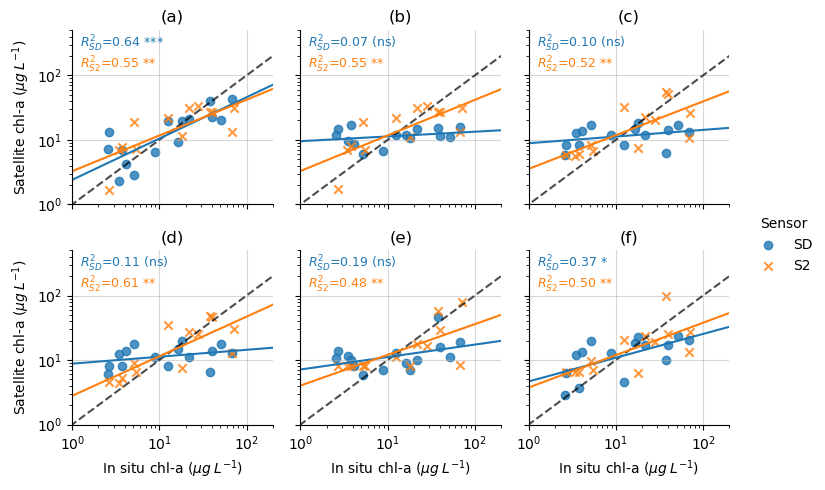

In [52]:
def annotate(data, x='Chl-a', y='sdfkjdf', order=1,
             plot=True, lims=None, text_size=9., **kws):
    
    ax = plt.gca()
    if data.Algorithm.values[0] == 'RBR3_orig_5':
        text_locs = ((0.6, 0.16), (0.6, 0.04))
    else:
        text_locs = ((0.04, 0.9), (0.04, 0.78))

    res = sp.stats.linregress(np.log10(data.dropna()[x]**order),
                              np.log10(data.dropna()[y]))
    if data.Sensor.values[0] == 'SD':
        textstr = '\n'.join((
#                              r'SuperDoves',
                             r'$R_{{SD}}^2$={:.2f} {}'.format(res.rvalue**2, p_sig(res.pvalue)),
#                              r'Slope = {:.2f}'.format(res.slope),
        ))
        ax.text(*text_locs[0], textstr, size=text_size,
            transform=ax.transAxes, bbox=None,
                color=sns.color_palette()[0])

        m = res.slope
        c = res.intercept

        if plot:
            ax.plot(np.logspace(-10, 4, num=1000),
                    10**((np.log10(np.logspace(-10, 4, num=1000)) * m) + c),
                    color=sns.color_palette()[0])

            
    if data.Sensor.values[0] == 'S2':
        textstr = '\n'.join((
#                              r'Sentinel-2',
                             r'$R_{{S2}}^2$={:.2f} {}'.format(res.rvalue**2, p_sig(res.pvalue)),
#                              r'Slope = {:.2f}'.format(res.slope),
                                ))
        ax.text(*text_locs[1], textstr, size=text_size,
            transform=ax.transAxes, bbox=None,
                color=sns.color_palette()[1])

        m = res.slope

        c = res.intercept

        if plot:
            ax.plot(np.logspace(-10, 4, num=1000),
                    10**((np.log10(np.logspace(-10, 4, num=1000)) * m) + c),
                    color=sns.color_palette()[1])
    print('m = ' + str(m))
    print('R2 = ' + str(res.rvalue**2))


    

g = sns.lmplot(data=insit_melt[(insit_melt.date_diff <= '1 days')& tuned],
               x='Chl-a', y='Satellite_chla', col='Algorithm', hue='Sensor',
               ci=None, fit_reg=False,
               col_wrap=3, markers=['o', 'x'],
               col_order=['OC3_X_tuned', 'OC2_X_tuned', 'NIR_tuned',
                           'NDCI_tuned', 'RBD_tuned', 'RBR3_tuned',
                          ],
               facet_kws={'sharey':True, 'sharex':True}, height=2.5)

g.set_titles("{col_name}")


# ylims = np.array([[0.1,500], [0.08,500], [1,500], [5,500], [0.3,500], [0.1,500]])
titles = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

for i, ax in enumerate(g.axes):
#     ax.set_xlim(0.1, 5e2)
#     ax.set_ylim(0.1, 5e2)
#     ax.plot([1e0, 100], [1e0, 100], 'k--', alpha=0.6)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ax.set_yscale('log')
    ax.set_xscale('log')


    lims = [np.min([xlim, ylim]), np.max([xlim, ylim])]
    ax.plot(np.logspace(-2, 3), np.logspace(-2, 3),
            'k--', alpha=0.7)
    
#     ax.set_ylim(ylims[i, 0], ylims[i, 1])
    ax.set_ylim(1, 500)
    ax.set_xlim(1, 200)
    ax.grid(alpha=0.5)
    if i in [3, 4, 5]:
        ax.set_xlabel('In situ chl-a ($\mu g \: L^{-1}$)')
    else:
        ax.set_xlabel('')
    if i in [0, 3]:
        ax.set_ylabel('Satellite chl-a ($\mu g \: L^{-1}$)')
    else:
        ax.set_ylabel('')
    ax.set_title(titles[i])

# plt.savefig('figures_for_paper/alg_comparison_NOT.svg', dpi=300)

g.map_dataframe(annotate, y='Satellite_chla', plot=True, offset=10)# lims=[0.1, 100])

for i, ax in enumerate(g.axes):
    ax.set_ylabel('Satellite chl-a ($\mu g \: L^{-1}$)')

plt.savefig('figures_for_paper/SD_S2_chla_tuned.svg', dpi=300)

    
plt.show()

In [68]:
indi = (insit_melt.date_diff <= '1 days')& tuned

metrics = insit_melt[indi].groupby(['Algorithm',
                                    'Sensor']).apply(r2_rmse,
                                                      )
metrics = metrics.reset_index()
metrics[metrics.Sensor=='S2']

,Algorithm,Sensor,r2,p_val,slope,rmse,mapd,mavd
0,NDCI_tuned,S2,0.613720,0.001535,0.613720,1.007210,20.236295,-1.554312e-15
2,NIR_tuned,S2,0.523037,0.005211,0.523037,1.168903,29.659008,2.220446e-16
4,OC2_X_tuned,S2,0.551305,0.003649,0.551305,1.118967,19.184179,8.881784e-16
6,OC3_X_tuned,S2,0.554240,0.003512,0.554240,1.113760,19.374948,8.881784e-16
8,RBD_tuned,S2,0.476186,0.009043,0.476186,1.250957,22.670678,-5.551115e-16
10,RBR3_tuned,S2,0.502125,0.006702,0.502125,1.205628,26.713975,0.000000e+00


In [69]:
# NIR_orig	S2	0.684090	0.000486	0.927756	1.569680	27.388547	0.859274

In [70]:
metrics[metrics.Sensor=='SD']

,Algorithm,Sensor,r2,p_val,slope,rmse,mapd,mavd
1,NDCI_tuned,SD,0.107520,0.232818,0.107520,1.808674,39.634362,1.554312e-15
3,NIR_tuned,SD,0.103369,0.242592,0.103369,1.815419,39.015686,-6.661338e-16
5,OC2_X_tuned,SD,0.073480,0.328449,0.073480,1.864008,33.264274,-6.661338e-16
7,OC3_X_tuned,SD,0.640506,0.000339,0.640506,0.925970,17.993573,1.110223e-15
9,RBD_tuned,SD,0.193145,0.101190,0.193145,1.669588,30.615349,-3.330669e-16
11,RBR3_tuned,SD,0.368284,0.016444,0.368284,1.384150,22.588155,2.220446e-16


In [72]:
metrics.to_clipboard()

In [75]:
metrics.mavd.values[10]

0.0

In [76]:
metrics['r2_1'] = 1 - metrics.r2
metrics['slope_1'] = np.abs(1 - metrics.slope)
metrics['abs_mavd'] = np.abs(metrics.mavd)

In [80]:
for metr in ['r2_1', 'slope_1', 'rmse', 'mapd', 'abs_mavd']:
    metrics[metr+'_rank'] = metrics.groupby(['Sensor',])[metr].rank('min')

metrics

metrics['rank_total'] = metrics[['r2_1_rank', 'slope_1_rank',
                                 'rmse_rank', 'mapd_rank',]].sum(axis=1)

In [81]:
metrics[metrics.Sensor=='SD']

,Algorithm,Sensor,r2,p_val,slope,rmse,mapd,mavd,r2_1,slope_1,abs_mavd,r2_1_rank,slope_1_rank,rmse_rank,mapd_rank,abs_mavd_rank,rank_total
1,NDCI_tuned,SD,0.107520,0.232818,0.107520,1.808674,39.634362,1.554312e-15,0.892480,0.892480,1.554312e-15,4.0,4.0,4.0,6.0,6.0,18.0
3,NIR_tuned,SD,0.103369,0.242592,0.103369,1.815419,39.015686,-6.661338e-16,0.896631,0.896631,6.661338e-16,5.0,5.0,5.0,5.0,3.0,20.0
5,OC2_X_tuned,SD,0.073480,0.328449,0.073480,1.864008,33.264274,-6.661338e-16,0.926520,0.926520,6.661338e-16,6.0,6.0,6.0,4.0,3.0,22.0
7,OC3_X_tuned,SD,0.640506,0.000339,0.640506,0.925970,17.993573,1.110223e-15,0.359494,0.359494,1.110223e-15,1.0,1.0,1.0,1.0,5.0,4.0
9,RBD_tuned,SD,0.193145,0.101190,0.193145,1.669588,30.615349,-3.330669e-16,0.806855,0.806855,3.330669e-16,3.0,3.0,3.0,3.0,2.0,12.0
11,RBR3_tuned,SD,0.368284,0.016444,0.368284,1.384150,22.588155,2.220446e-16,0.631716,0.631716,2.220446e-16,2.0,2.0,2.0,2.0,1.0,8.0


In [82]:
metrics[metrics.Sensor=='S2']

,Algorithm,Sensor,r2,p_val,slope,rmse,mapd,mavd,r2_1,slope_1,abs_mavd,r2_1_rank,slope_1_rank,rmse_rank,mapd_rank,abs_mavd_rank,rank_total
0,NDCI_tuned,S2,0.613720,0.001535,0.613720,1.007210,20.236295,-1.554312e-15,0.386280,0.386280,1.554312e-15,1.0,1.0,1.0,3.0,6.0,6.0
2,NIR_tuned,S2,0.523037,0.005211,0.523037,1.168903,29.659008,2.220446e-16,0.476963,0.476963,2.220446e-16,4.0,4.0,4.0,6.0,2.0,18.0
4,OC2_X_tuned,S2,0.551305,0.003649,0.551305,1.118967,19.184179,8.881784e-16,0.448695,0.448695,8.881784e-16,3.0,3.0,3.0,1.0,4.0,10.0
6,OC3_X_tuned,S2,0.554240,0.003512,0.554240,1.113760,19.374948,8.881784e-16,0.445760,0.445760,8.881784e-16,2.0,2.0,2.0,2.0,4.0,8.0
8,RBD_tuned,S2,0.476186,0.009043,0.476186,1.250957,22.670678,-5.551115e-16,0.523814,0.523814,5.551115e-16,6.0,6.0,6.0,4.0,3.0,22.0
10,RBR3_tuned,S2,0.502125,0.006702,0.502125,1.205628,26.713975,0.000000e+00,0.497875,0.497875,0.000000e+00,5.0,5.0,5.0,5.0,1.0,20.0


# we find that OC3 is best for SD and S2

In [86]:
insit_melt['year'] = insit_melt.Date.dt.year

In [87]:
m_years = mdates.YearLocator()   # every year
m_months = mdates.MonthLocator()  # every month
monthsFmt = mdates.DateFormatter('%b \'%y')

In [88]:
sd_chla

,date,Rrs_444,Rrs_492,Rrs_533,Rrs_566,Rrs_612,Rrs_666,Rrs_707,Rrs_866,NIR,...,OC2,OC2_tuned,OC3_tuned,OC4_tuned,NIR_tuned,NDCI_tuned,RBD_tuned,RBR3_tuned,OC2_X_tuned,OC3_X_tuned
0,2020-04-07,0.006075,0.006498,0.007883,0.007561,0.007404,0.007559,0.011126,0.019176,1.471865,...,2.370275,6.138566,4.611066,3.295334,15.423063,15.604149,8.298480,17.303346,6.869196,7.026190
1,2020-09-18,0.008708,0.009085,0.011386,0.011201,0.009268,0.007399,0.011143,0.024900,1.506014,...,2.702911,5.689678,4.858118,3.590632,14.866159,14.878552,8.662796,13.646352,7.413647,8.318590
2,2020-09-26,0.004379,0.003255,0.005032,0.004621,0.005592,0.002707,0.005821,0.015998,2.150635,...,3.849362,5.860173,4.859968,3.146508,7.425121,7.350224,7.435982,2.985975,8.930735,5.282956
3,2020-11-19,0.011241,0.010825,0.011702,0.009393,0.009546,0.007786,0.010998,0.013881,1.412442,...,1.335143,0.582998,4.655300,5.845651,16.442324,17.006698,7.612838,21.538075,4.666014,2.673923
4,2020-11-25,0.014203,0.015736,0.017705,0.015108,0.012218,0.012235,0.013204,0.014211,1.079213,...,1.603979,3.614712,5.416500,3.885566,23.540600,30.187259,4.419211,29.827579,5.331874,4.010137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,2024-03-04,0.004763,0.003221,0.004114,0.004314,0.004615,0.004335,0.006261,0.009583,1.444086,...,3.306062,5.453219,5.501898,3.187189,15.891433,16.236341,5.572710,19.120385,8.269560,3.380875
186,2024-03-16,0.009701,0.007298,0.007646,0.008042,0.008940,0.008062,0.013988,0.022267,1.734916,...,2.108345,6.396328,4.498918,4.613052,11.618207,11.150089,14.703287,13.251738,6.394142,2.612685
187,2024-03-22,0.005037,0.004842,0.005544,0.006437,0.006043,0.004854,0.007934,0.013866,1.634716,...,3.245629,5.440852,5.224981,13.015855,12.942066,12.573052,7.375107,13.866791,8.190210,9.240870
188,2024-03-31,0.012043,0.011350,0.013888,0.013879,0.013738,0.014499,0.021838,0.037212,1.506166,...,2.652269,5.747273,4.603440,3.864845,14.863721,14.875436,20.716711,16.677457,7.334527,6.832734


Axes(0.125,0.53;0.352273x0.35)
['SuperDoves OC3', 'SuperDoves OC3', 'Insitu']
Axes(0.547727,0.53;0.352273x0.35)
['SuperDoves OC3', 'SuperDoves OC3', 'Insitu']
Axes(0.125,0.11;0.352273x0.35)
['Sentinel-2 NDCI', 'Sentinel-2 NDCI', 'Insitu']
Axes(0.547727,0.11;0.352273x0.35)
['Sentinel-2 NDCI', 'Sentinel-2 NDCI', 'Insitu']


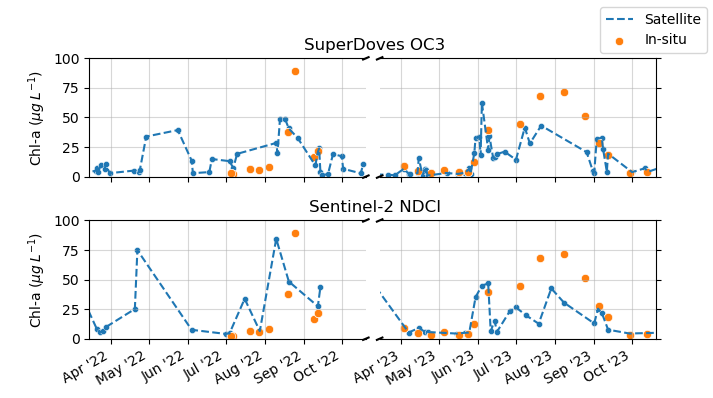

In [89]:
fig, axs = plt.subplots(2, 2, figsize=(7, 4), sharey=True)

algs = ['OC3_X_tuned', 'NDCI_tuned']
labs = ['SuperDoves OC3', 'Sentinel-2 NDCI']
dfs = [sd_chla, s2_chla]

for axi, alg, df, lab in zip([0, 1], algs, dfs, labs):
    
    for yr, axj in zip([2022, 2023], [0, 1]):
        sns.lineplot(data=df[df.date.dt.year.isin([yr])],
                        x='date', y=alg, label=lab, ax=axs[axi, axj], errorbar=None,
                     color=sns.color_palette()[0], linestyle='--',
                     legend=False
                       )
        sns.scatterplot(data=df[df.date.dt.year.isin([yr])],
                        x='date', y=alg, label=lab, ax=axs[axi, axj], 
                     color=sns.color_palette()[0], s=20,
                     legend=False
                       )

        axs[axi, 0].set_title('                                                        ' + lab)
        



# hide the spines between ax and ax2



for ax in axs.flatten():
    sns.scatterplot(data=insit_melt[(insit_melt.Algorithm=='OC3_tuned')&(insit_melt.year.isin([2022,2023]))],
                x='Date', y='Chl-a', label='Insitu', ax=ax, #marker='o', color='g',
                    color=sns.color_palette()[1], legend=False,
                )
    

axs[0, 0].set_xlim(pd.to_datetime('2022-03-15'), pd.to_datetime('2022-10-20'))
axs[1, 0].set_xlim(pd.to_datetime('2022-03-15'), pd.to_datetime('2022-10-20'))
axs[1, 1].set_xlim(pd.to_datetime('2023-03-15'), pd.to_datetime('2023-10-20'))
axs[0, 1].set_xlim(pd.to_datetime('2023-03-15'), pd.to_datetime('2023-10-20'))
    
for ax, ax2 in [(axs[0, 0], axs[0, 1]), (axs[1, 0], axs[1, 1])]:
    ax.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax.yaxis.tick_left()
#     ax.tick_params(labelright='off')
    ax2.yaxis.tick_right()
    
    d = .01  # how big to make the diagonal lines in axes coordinates
    # arguments to pass plot, just so we don't keep repeating them
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
    ax.plot((1-d, 1+d), (-d, +d), **kwargs)
    ax.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

    kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
    ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
    ax2.plot((-d, +d), (-d, +d), **kwargs)
    
for ax in axs.flatten():
#     ax.set_ylim(0, 120)
    print(ax)
    ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
    ax.set_xlabel('')
#     ax.xaxis.set_major_locator(m_months)
    ax.xaxis.set_major_formatter(monthsFmt)
#     ax.xaxis.set_major_locator(m_months)
    ax.grid(alpha=0.5)
    ax.legend()
    h, l = ax.get_legend_handles_labels()
    print(l)
    ax.get_legend().remove()
    ax.set_ylim(0, 100)


    
fig.legend(handles=[item for item in [h[0], h[2]]], labels= ['Satellite',
                                                      'In-situ'])
fig.autofmt_xdate()
plt.tight_layout(rect=(0, 0, 0.95, 0.95))

fig.subplots_adjust(wspace=0.05)

# plt.savefig('figures_for_paper/SD_S2_insitu_chla_timeseries.svg', dpi=300)

plt.show()



In [1]:
insit_melt

NameError: name 'insit_melt' is not defined

In [90]:
insit_melt[(insit_melt.Date>='2023-05-14') & (insit_melt.Date<='2023-06-09') & (insit_melt.Algorithm=='OC3_tuned')]
# insit_melt.Date.unique()

,Date,Chl-a,sat_date,date_diff,Algorithm,Satellite_chla,Sensor,year
81,2023-05-17,3.483,2023-05-16,1 days,OC3_tuned,3.364128,SD,2023
82,2023-05-24,3.776,2023-05-25,1 days,OC3_tuned,4.605658,SD,2023
83,2023-05-29,12.530,2023-05-29,0 days,OC3_tuned,20.592284,SD,2023
84,2023-06-09,39.744,2023-06-09,0 days,OC3_tuned,28.604377,SD,2023
26,2023-05-17,3.483,2023-05-15,2 days,OC3_tuned,0.160082,S2,2023
27,2023-05-24,3.776,2023-05-25,1 days,OC3_tuned,6.295987,S2,2023
28,2023-05-29,12.530,2023-05-30,1 days,OC3_tuned,18.182919,S2,2023
29,2023-06-09,39.744,2023-06-09,0 days,OC3_tuned,21.193913,S2,2023


In [109]:
sd_chla.columns

Index(['date', 'Rrs_444', 'Rrs_492', 'Rrs_533', 'Rrs_566', 'Rrs_612',
       'Rrs_666', 'Rrs_707', 'Rrs_866', 'NIR', 'NDCI', 'RBD', 'RBR3',
       'NIR_org', 'NDCI_org', 'RBD_org', 'RBR3_org', 'OC4_X', 'OC4_mod_X',
       'OC3_X', 'OC2_X', 'OC4', 'OC3', 'OC2', 'OC2_tuned', 'OC3_tuned',
       'OC4_tuned', 'NIR_tuned', 'NDCI_tuned', 'RBD_tuned', 'RBR3_tuned',
       'OC2_X_tuned', 'OC3_X_tuned'],
      dtype='object')

In [231]:
dfs

[          date   Rrs_444   Rrs_492   Rrs_533   Rrs_566   Rrs_612   Rrs_666  \
 0   2020-04-07  0.006075  0.006498  0.007883  0.007561  0.007404  0.007559   
 1   2020-09-18  0.008708  0.009085  0.011386  0.011201  0.009268  0.007399   
 2   2020-09-26  0.004379  0.003255  0.005032  0.004621  0.005592  0.002707   
 3   2020-11-19  0.011241  0.010825  0.011702  0.009393  0.009546  0.007786   
 4   2020-11-25  0.014203  0.015736  0.017705  0.015108  0.012218  0.012235   
 ..         ...       ...       ...       ...       ...       ...       ...   
 185 2024-03-04  0.004763  0.003221  0.004114  0.004314  0.004615  0.004335   
 186 2024-03-16  0.009701  0.007298  0.007646  0.008042  0.008940  0.008062   
 187 2024-03-22  0.005037  0.004842  0.005544  0.006437  0.006043  0.004854   
 188 2024-03-31  0.012043  0.011350  0.013888  0.013879  0.013738  0.014499   
 189 2024-04-08  0.004591  0.003980  0.006642  0.007441  0.006644  0.007170   
 
       Rrs_707   Rrs_866       NIR  ...       OC2 

Axes(0.125,0.11;0.352273x0.77)
['SuperDoves OC3', 'Sentinel-2 OC3', 'Insitu']
Axes(0.547727,0.11;0.352273x0.77)
['SuperDoves OC3', 'Sentinel-2 OC3', 'Insitu']


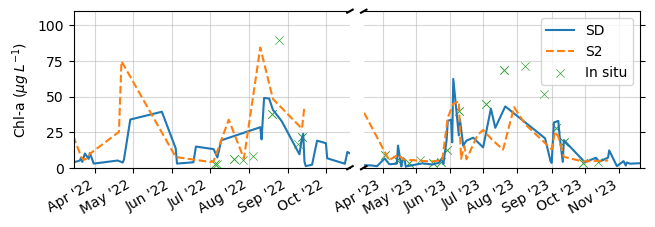

In [115]:
fig, axs = plt.subplots(1, 2, figsize=(7, 2.5), sharey=True)

algs = ['OC3_X_tuned', 'NDCI_tuned']
labs = ['SuperDoves OC3', 'Sentinel-2 OC3']
dfs = [sd_chla, s2_chla]

for axi, color, alg, df, lab, st in zip([0, 1], [sns.color_palette()[0], sns.color_palette()[1]], 
                                    algs, dfs, labs, ['-', '--']):
    
    for yr, axj in zip([2022, 2023], [0, 1]):
        sns.lineplot(data=df[df.date.dt.year.isin([yr])],
                        x='date', y=alg, label=lab, ax=axs[axj], errorbar=None,
                     color=color, linestyle=st,
                     legend=False, 
                       )
#         sns.scatterplot(data=df[df.date.dt.year.isin([yr])],
#                         x='date', y=alg, label=lab, ax=axs[axj], 
#                      color=color, s=20,
#                      legend=False,  
#                        )

#         axs[0].set_title('                                                        ' + lab)
        



# hide the spines between ax and ax2



for ax in axs.flatten():
    sns.scatterplot(data=insit_melt[(insit_melt.Algorithm=='OC3_tuned')&(insit_melt.year.isin([2022,2023]))],
                x='Date', y='Chl-a', label='Insitu', ax=ax, marker='x',
                    color=sns.color_palette()[2], legend=False,
                )
    

axs[0].set_xlim(pd.to_datetime('2022-03-15'), pd.to_datetime('2022-10-20'))
axs[1].set_xlim(pd.to_datetime('2023-03-15'), pd.to_datetime('2023-11-20'))
# axs[1, 1].set_xlim(pd.to_datetime('2023-03-15'), pd.to_datetime('2023-10-20'))
# axs[0, 1].set_xlim(pd.to_datetime('2023-03-15'), pd.to_datetime('2023-10-20'))
    
for ax, ax2 in [(axs[0], axs[1])]:
    ax.spines['right'].set_visible(False)
    ax2.spines['left'].set_visible(False)
    ax.yaxis.tick_left()
#     ax.tick_params(labelright='off')
    ax2.yaxis.tick_right()
    
    d = .01  # how big to make the diagonal lines in axes coordinates
    # arguments to pass plot, just so we don't keep repeating them
    kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
    ax.plot((1-d, 1+d), (-d, +d), **kwargs)
    ax.plot((1-d, 1+d), (1-d, 1+d), **kwargs)

    kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
    ax2.plot((-d, +d), (1-d, 1+d), **kwargs)
    ax2.plot((-d, +d), (-d, +d), **kwargs)
    
for ax in axs.flatten():
#     ax.set_ylim(0, 120)
    print(ax)
    ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
    ax.set_xlabel('')
#     ax.xaxis.set_major_locator(m_months)
    ax.xaxis.set_major_formatter(monthsFmt)
    
#     ax.xaxis.set_major_locator(m_months)
    ax.grid(alpha=0.5)
    ax.legend()
    h, l = ax.get_legend_handles_labels()
    print(l)
    ax.get_legend().remove()
    ax.set_ylim(0, 110)


    
axs[1].legend(handles=[item for item in [h[0], h[1], h[2]]], labels= ['SD', 'S2',
                                                      'In situ'], loc='upper right')
fig.autofmt_xdate()
plt.tight_layout(rect=(0, 0, 0.95, 0.95))

fig.subplots_adjust(wspace=0.05)

plt.savefig('figures_for_paper/SD_S2_insitu_chla_timeseries.svg', dpi=300)

plt.show()



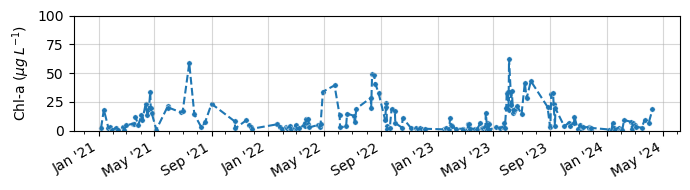

In [221]:
fig, ax = plt.subplots(1, 1, figsize=(7, 2.))
sns.lineplot(data=sd_chla[sd_chla.date.dt.year!=2020],
             x='date', y='OC3_X_tuned', ax=ax,
                     color=sns.color_palette()[0], linestyle='--',
                     legend=False
                       )
sns.scatterplot(data=sd_chla[sd_chla.date.dt.year!=2020],
             x='date', y='OC3_X_tuned', ax=ax,
                     color=sns.color_palette()[0],
                s=15,
                       )
ax.grid(alpha=0.5)
ax.xaxis.set_major_formatter(monthsFmt)
ax.xaxis.set_minor_locator(m_months)
fig.autofmt_xdate()
ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
ax.set_xlabel('')
ax.set_ylim(0., 100)

plt.tight_layout()
# plt.savefig('figures_for_paper/SD_chla_timeseries.svg', dpi=300)
    


plt.show()


In [117]:
SEPA_blooms = pd.DataFrame({'Date':['15-06-2021', '17-08-2021', '02-05-2022',
                                    '22-06-2022', '26-10-2022'],
                            'Bloom':[False, False, True, False, False,]
                            })

BA_blooms = pd.DataFrame({'Date':['28-04-2022', '10-05-2022', '15-08-2022', '18-08-2022',
                                     '01-06-2023'],
                            'Bloom':[True, True, True, True, True]})

In [118]:
SEPA_blooms.Date = pd.to_datetime(SEPA_blooms.Date, format='%d-%m-%Y')
BA_blooms.Date = pd.to_datetime(BA_blooms.Date, format='%d-%m-%Y')

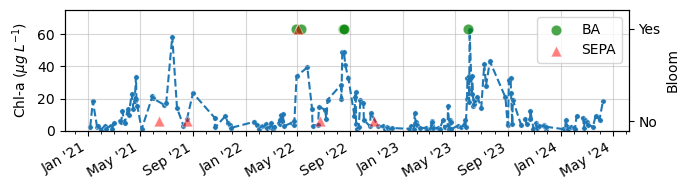

In [183]:
fig, ax = plt.subplots(1, 1, figsize=(7, 2.))
sns.lineplot(data=sd_chla[sd_chla.date.dt.year!=2020],
             x='date', y='OC3_X_tuned', ax=ax,
                     color=sns.color_palette()[0], linestyle='--',
                     legend=False
                       )
sns.scatterplot(data=sd_chla[sd_chla.date.dt.year!=2020],
             x='date', y='OC3_X_tuned', ax=ax,
                     color=sns.color_palette()[0],
                s=15,
                       )
ax.grid(alpha=0.5)
ax.xaxis.set_major_formatter(monthsFmt)
ax.xaxis.set_minor_locator(m_months)
fig.autofmt_xdate()
ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
ax.set_xlabel('')
ax.set_ylim(0., 75)

ax_bloom = ax.twinx()

sns.scatterplot(data=BA_blooms, x='Date', y='Bloom',
                ax=ax_bloom, marker='o', color='green',
                label="BA", alpha=0.7, s=60)

sns.scatterplot(data=SEPA_blooms, x='Date', y='Bloom',
                ax=ax_bloom, marker='^', color='r',
                label='SEPA', alpha=0.5, s=60)



ax_bloom.set_yticks([0, 1])
ax_bloom.set_yticklabels(['No', 'Yes'])
ax_bloom.set_ylim(-0.1, 1.2)

ax_bloom.legend(loc='upper right')


plt.tight_layout()
plt.savefig('figures_for_paper/SD_chla_timeseries_blooms.svg', dpi=300)
    


plt.show()

[ 0  5 10 15 20 25 30 35 40 45 50 55]


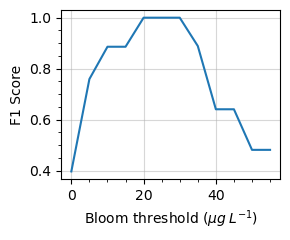

In [219]:
total_blooms = np.array([0, 0, 1, 1, 1, 0, 1, 0, 1])
SD_blooms = np.array([16, 7, 34, 39, 39, 3, 49, 4, 62])
SD_blooms > 26.78459999999998
scores = []
thresholds = np.arange(0, 60, 5)
print(thresholds)
for thresh in thresholds:
    scores.append(f1_score(total_blooms, SD_blooms > thresh, average='weighted'), )
    
fig, ax = plt.subplots(1, 1, figsize=(3, 2.5))
ax.plot(thresholds, scores)
ax.set_xlabel('Bloom threshold ($\mu g \: L^{-1}$)')
ax.set_ylabel('F1 Score')
ax.minorticks_on()
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('figures_for_paper/SD_SEPA_BA_F1_score.svg', dpi=300)
plt.show()

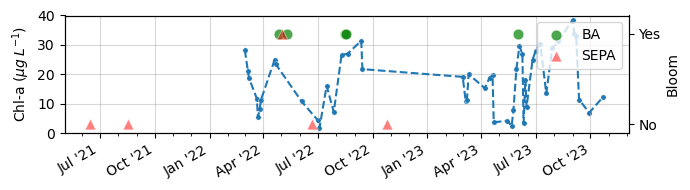

In [167]:
fig, ax = plt.subplots(1, 1, figsize=(7, 2.))
sns.lineplot(data=s2_chla[s2_chla.date.dt.year!=2020],
             x='date', y='OC3_X_tuned', ax=ax,
                     color=sns.color_palette()[0], linestyle='--',
                     legend=False
                       )
sns.scatterplot(data=s2_chla[s2_chla.date.dt.year!=2020],
             x='date', y='OC3_X_tuned', ax=ax,
                     color=sns.color_palette()[0],
                s=15,
                       )
ax.grid(alpha=0.5)
ax.xaxis.set_major_formatter(monthsFmt)
ax.xaxis.set_minor_locator(m_months)
fig.autofmt_xdate()
ax.set_ylabel('Chl-a ($\mu g \: L^{-1}$)')
ax.set_xlabel('')
ax.set_ylim(0., 40)

ax_bloom = ax.twinx()

sns.scatterplot(data=BA_blooms, x='Date', y='Bloom',
                ax=ax_bloom, marker='o', color='green',
                label="BA", alpha=0.7, s=60)

sns.scatterplot(data=SEPA_blooms, x='Date', y='Bloom',
                ax=ax_bloom, marker='^', color='r',
                label='SEPA', alpha=0.5, s=60)



ax_bloom.set_yticks([0, 1])
ax_bloom.set_yticklabels(['No', 'Yes'])
ax_bloom.set_ylim(-0.1, 1.2)

ax_bloom.legend(loc='upper right')


plt.tight_layout()
# plt.savefig('figures_for_paper/SD_chla_timeseries_blooms.svg', dpi=300)
    


plt.show()

# now have an issue:

- basically, Planet SR product appears to be better than acolite BUT:
- but when I plot the long term time series, we don't see peaks coming through properly
- long term chl-a time series looks better with OC3 superdoves acolite
- I think the issue is that although the errors on the SR atmospheric correction are generally lower, the slopes are all less steep, meaning a less sensitive response to changes in the optical properties of the water
- additionally, the R^2 is generally better for acolite (when compared with DALEC data)

- just need a way to justify that ACOLITE is best to use!

# solution:
- note that acolite and SR performance is actually very similar! 
- but, using the following metrics, we find acolite ever so slightly outperforms SR:
    - R2, slope, MAPD, RMSE, MAvD
- whilst this might seem a bit hacky (if I chose MAE over RMSE, we'd find SR outperforms acolite), we can still highlight how acolite and SR appear very similar in performance.
- further, we avoid needing to present results from both SR and acolite, which I think takes away from the overall message!

# now going to work on thresholds analysis

- hard to find a sensible threshold in the literature
- therefore, seeing as this is basically just a demo, we'll use a percentile: 66.67 % 
- ie. assume that the highest 1/3 of the data would be a cause for concern

In [122]:
f1_score([1, 0, 0, 0, 1, 1, 1], [0, 0, 0, 0, 1, 1, 1], average='weighted')

0.8571428571428571

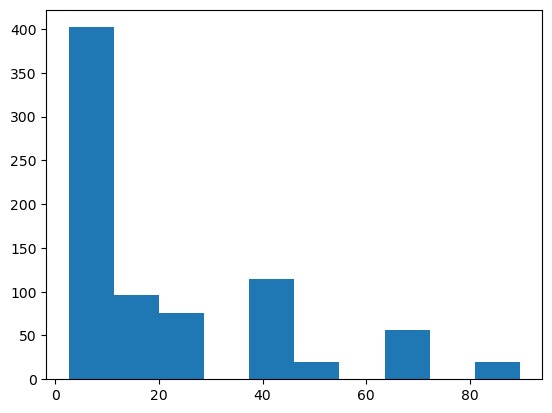

In [123]:
plt.hist(insit_melt['Chl-a'])

plt.show()

In [181]:
THRESH_67 = np.percentile(insit_melt['Chl-a'].unique(), 75)
THRESH_67

37.789

In [160]:
insit_melt

,Date,Chl-a,sat_date,date_diff,Algorithm,Satellite_chla,Sensor,year
0,2022-07-05,2.663,2022-07-04,1 days,OC4,6.730458,SD,2022
1,2022-07-07,2.592,2022-07-07,0 days,OC4,3.270449,SD,2022
2,2022-07-20,6.163,2022-07-10,10 days,OC4,3.452151,SD,2022
3,2022-08-04,8.361,2022-08-10,6 days,OC4,3.948760,SD,2022
4,2022-08-19,37.789,2022-08-20,1 days,OC4,4.268469,SD,2022
...,...,...,...,...,...,...,...,...
319,2023-07-20,68.487,2023-07-19,1 days,RBR3_orig+5,1.300693,S2,2023
320,2023-08-08,71.458,2023-08-08,0 days,RBR3_orig+5,1.693837,S2,2023
321,2023-09-05,28.054,2023-09-04,1 days,RBR3_orig+5,1.498924,S2,2023
322,2023-09-12,18.055,2023-09-12,0 days,RBR3_orig+5,0.875929,S2,2023


In [161]:
def F1_above_thresh(y_true, y_pred, thresh=20):
    '''
    calculates F1 score by first categorising the data into above/below the given threshold
    '''
    yt = y_true > thresh
    yp = y_pred > thresh
    return f1_score(yt, yp, average='weighted'
                   )

In [162]:
def f1_df(g, thresh=THRESH_67):
    try:
        x = g.dropna()['Chl-a']
        y = g.dropna()['Satellite_chla']
        
        f1 = F1_above_thresh(x, y, thresh=thresh)
            
        
        return pd.Series(dict(f1 = f1,
                                        ))
    except ValueError:
        return pd.Series(dict(f1 = np.nan,
                              
                                          ))

In [163]:
indi = (insit_melt.date_diff <= '1 days')& tuned

metrics_f1 = insit_melt[indi].groupby(['Sensor', 
                                       'Algorithm']).apply(f1_df,
                                                      )
metrics_f1 = metrics_f1.reset_index()
metrics_f1

,Sensor,Algorithm,f1
0,S2,NDCI_tuned,0.751648
1,S2,NIR_tuned,0.751648
2,S2,OC2_X_tuned,0.668896
3,S2,OC3_X_tuned,0.668896
4,S2,RBD_tuned,0.751648
5,S2,RBR3_tuned,0.629371
6,SD,NDCI_tuned,0.711111
7,SD,NIR_tuned,0.711111
8,SD,OC2_X_tuned,0.711111
9,SD,OC3_X_tuned,0.784000


In [224]:
thresholds = np.arange(10, 60, 5)
f1_SD_OC3 = []
f1_S2_OC3 = []

for threshold in thresholds:
    metrs_f1 = insit_melt[indi].groupby(['Sensor', 
                                       'Algorithm']).apply(f1_df, thresh=threshold
                                                      ).reset_index()
    f1_SD_OC3.append(metrs_f1[(metrs_f1.Sensor=='SD')&(metrs_f1.Algorithm=='OC3_X_tuned')].f1.values[0])
    f1_S2_OC3.append(metrs_f1[(metrs_f1.Sensor=='S2')&(metrs_f1.Algorithm=='NDCI_tuned')].f1.values[0])

In [225]:
thresholds

array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55])

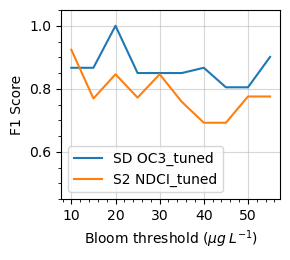

In [230]:
fig, ax = plt.subplots(figsize=(3, 2.7))
plt.plot(thresholds, f1_SD_OC3, label='SD OC3_tuned')
plt.plot(thresholds, f1_S2_OC3, label='S2 NDCI_tuned')
plt.legend(loc='lower left')

plt.ylim(0.45, 1.05)
ax.set_xlabel('Bloom threshold ($\mu g \: L^{-1}$)')
ax.set_ylabel('F1 Score')
ax.minorticks_on()
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('figures_for_paper/SD_S2_F1_score.svg', dpi=300)

# find best F1 score of 0.93 for SD with OC3
# best S2 F1 is 0.85 using either RBR3, RBD, or OC3, or OC2

## generally S2 is not very sensitive to algorithm choice, but SD really is!

the above plot is useful just to understand the effect of changing the threshold 